<a href="https://colab.research.google.com/github/ArunimaR622/OBESITY-ANALYSIS-USING-LIFESTYLE-AND-EATING-HABITS/blob/PHASE4--FINAL-PROJECT/Obesity_Analysis_Using_Lifestyle_and_Eating_Habits_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**<h1 style="font-size:40px;">OBESITY ANALYSIS USING LIFESTYLE AND EATING HABITS</h1>**


**<H1>Aim of the Study</H1>**

The aim of this study is to analyze how eating habits, lifestyle behaviors, and physical activity patterns influence obesity levels using data-driven techniques. The study seeks to uncover meaningful relationships within the dataset and build actionable insights that can support obesity risk assessment and prevention.

**<H1>Problem Definition</H1>**

Obesity is influenced by a combination of dietary behavior, lifestyle patterns, and physical activity levels. However, identifying which specific habits contribute most to obesity remains a significant challenge. The dataset contains multiple behavioral and physical attributes, but without proper analysis, the relationship between these factors and obesity levels is not clearly understood.

This project aims to define, analyze, and quantify how daily habits—such as food consumption patterns, snacking behavior, water intake, and physical activity—affect obesity levels. The core problem is to determine which lifestyle factors have the strongest impact on obesity and to use data-driven techniques to classify individuals based on their obesity risk.

**<H1>Data Source</H1>**

The dataset used in this study is obtained from the
UCI Machine Learning Repository

Dataset Name: Estimation of Obesity Levels Based on Eating Habits and Physical Condition

Source URL: UCI Repository (ID: 544)


**<H1>Dataset Description</H1>**

The dataset for this study originates from the UCI Machine Learning Repository and is titled “Estimation of Obesity Levels Based on Eating Habits and Physical Condition.” It contains 2,111 observations and a diverse collection of attributes that describe individual demographics, eating behaviors, lifestyle choices, and physical health measures. The demographic attributes include gender, age, and family history of overweight. Eating habits are captured through variables such as frequency of vegetable consumption, number of main meals per day, water intake, calorie consumption awareness, and snacking tendencies. Lifestyle-related variables include physical activity frequency, smoking habits, time spent using digital devices, and preferred mode of transportation. Physical condition is represented through height, weight, and Body Mass Index (BMI), which help quantify obesity-related health indicators.
The target variable, NObesity, assigns each individual to specific obesity levels such as underweight, normal weight, overweight, and obesity type I, II, or III. The dataset contains a combination of numerical, ordinal, and categorical variables, making it suitable for comprehensive exploration, feature engineering, and predictive modeling. To support deeper analysis, additional derived features such as lifestyle scores, diet quality scores, activity scores, and binary behavior flags can be created during preprocessing. This dataset provides a rich foundation for understanding how daily habits and physical activity patterns influence obesity.

**<H1> Data Loading and initial overview</H1>**

This section loads the dataset into a pandas DataFrame. Pandas is used for structured data analysis, while NumPy supports numerical operations.

In [2]:
import pandas as pd
import numpy as np

In [3]:
from google.colab import files
uploaded = files.upload()

Saving ObesityDataSet_raw_and_data_sinthetic.csv to ObesityDataSet_raw_and_data_sinthetic.csv


In [4]:
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

***Basic Overview (shape, dtypes, head, info)***

This block provides an initial understanding of the dataset:

shape → number of rows & columns

dtypes → whether each column is numeric or categorical

head() → preview of first few rows

info() → missing values & memory usage

This is essential before any cleaning or modeling.

In [5]:
print("Shape of dataset:", df.shape)
print("\nColumn types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nStatistical Summary:")
display(df.describe(include="all"))

Shape of dataset: (2111, 17)

Column types:
Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                               float64
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object

First 5 rows:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
count,2111,2111.000000,2111.000000,2111.000000,2111,2111,2111.000000,2111.000000,2111,2111,2111.000000,2111,2111.000000,2111.000000,2111,2111,2111
unique,2,NaN,NaN,NaN,2,2,NaN,NaN,4,2,NaN,2,NaN,NaN,4,5,7
top,Male,NaN,NaN,NaN,yes,yes,NaN,NaN,Sometimes,no,NaN,no,NaN,NaN,Sometimes,Public_Transportation,Obesity_Type_I
freq,1068,NaN,NaN,NaN,1726,1866,NaN,NaN,1765,2067,NaN,2015,NaN,NaN,1401,1580,351
mean,NaN,24.312600,1.701677,86.586058,NaN,NaN,2.419043,2.685628,NaN,NaN,2.008011,NaN,1.010298,0.657866,NaN,NaN,NaN
std,NaN,6.345968,0.093305,26.191172,NaN,NaN,0.533927,0.778039,NaN,NaN,0.612953,NaN,0.850592,0.608927,NaN,NaN,NaN
min,NaN,14.000000,1.450000,39.000000,NaN,NaN,1.000000,1.000000,NaN,NaN,1.000000,NaN,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,19.947192,1.630000,65.473343,NaN,NaN,2.000000,2.658738,NaN,NaN,1.584812,NaN,0.124505,0.000000,NaN,NaN,NaN
50%,NaN,22.777890,1.700499,83.000000,NaN,NaN,2.385502,3.000000,NaN,NaN,2.000000,NaN,1.000000,0.625350,NaN,NaN,NaN
75%,NaN,26.000000,1.768464,107.430682,NaN,NaN,3.000000,3.000000,NaN,NaN,2.477420,NaN,1.666678,1.000000,NaN,NaN,NaN


**<H1> Data Preprocessing</H1>**

***Handling missing values***

Identifies missing (NaN) values in each column. This helps plan appropriate handling—either imputation or deletion.

In [6]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64


***Removing Duplicate Rows***

Duplicate rows can cause biased analysis. This step ensures each data point appears only once.

In [7]:
print("Duplicates before removal:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicates after removal:", df.duplicated().sum())

Duplicates before removal: 24
Duplicates after removal: 0


***Correcting Data Types***

In [8]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = df[col].astype("category")

print("\nUpdated column types:")
print(df.dtypes)


Updated column types:
Gender                            category
Age                                float64
Height                             float64
Weight                             float64
family_history_with_overweight    category
FAVC                              category
FCVC                               float64
NCP                                float64
CAEC                              category
SMOKE                             category
CH2O                               float64
SCC                               category
FAF                                float64
TUE                                float64
CALC                              category
MTRANS                            category
NObeyesdad                        category
dtype: object


***Creating Derived (New) Columns***

Numeric Conversion (FAF, CH2O, FCVC)

Some numeric values may be stored as strings. to_numeric() converts them to float, preparing them for mathematical operations.

In [9]:


numeric_cols = ["FAF", "CH2O", "FCVC"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

**Binary behavior Flags**

In [10]:
binary_columns = ["FAVC", "SMOKE", "SCC", "family_history_with_overweight"]

for col in binary_columns:
    df[col] = df[col].astype(str).str.strip().str.lower()

df["FAVC_flag"] = df["FAVC"].map({"yes": 1, "no": 0})
df["SMOKE_flag"] = df["SMOKE"].map({"yes": 1, "no": 0})
df["SCC_flag"] = df["SCC"].map({"yes": 1, "no": 0})
df["Family_history_flag"] = df["family_history_with_overweight"].map({"yes": 1, "no": 0})



**BMI**

BMI (Body Mass Index) is a standard measure of body fat. It becomes a foundation for obesity classification.

In [11]:
df["BMI"] = df["Weight"] / (df["Height"] ** 2)

**BMI Category**

Classifies individuals into Underweight, Normal, Overweight, Obesity I–III based on WHO guidelines. This helps in categorical analysis.

In [12]:
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    elif bmi < 35:
        return "Obesity I"
    elif bmi < 40:
        return "Obesity II"
    else:
        return "Obesity III"

df["BMI_Category"] = df["BMI"].apply(bmi_category)

**Physical activity per week**

Converts daily activity frequency (FAF) into weekly activity minutes.


In [13]:
df["Weekly_Physical_Activity"] = df["FAF"] * 7

**High-Calorie Food Consumption Flag**

Converts the "yes/no" text of high-calorie food consumption into numeric values.
 yes = 2 (high impact), no = 0.

In [14]:
df["FAVC_flag"] = df["FAVC"].map({"yes": 2, "no": 0})

In [15]:
df["FAVC"] = df["FAVC"].astype(str).str.strip().str.lower()
df["FAVC_flag"] = df["FAVC"].map({"yes": 2, "no": 0})

**Transportation flag**

Converts transportation method values into lowercase text to avoid mapping errors.

In [16]:
df["MTRANS"] = df["MTRANS"].astype(str).str.lower()

df["transport_flag"] = df["MTRANS"].map({
    "walking": 2,
    "bicycle": 2,
    "public_transportation": 1,
    "motorbike": -1,
    "automobile": -2
})

In [17]:
df[["FAF","CH2O","FCVC","FAVC_flag"]].dtypes

,0
FAF,float64
CH2O,float64
FCVC,float64
FAVC_flag,int64


**Lifestyle score**

A custom composite score created from physical activity, water intake, vegetable intake, and junk food consumption. Higher values indicate a healthier lifestyle.

In [18]:
df["Lifestyle_Score"] = (
    df["FAF"] * 2 +
    df["CH2O"] * 1.2 +
    df["FCVC"] * 1.5 +
    df["FAVC_flag"]
)


**Diet Quality score**

Creates a combined diet quality measure where healthy habits increase the score and unhealthy ones decrease it.

In [19]:
df["diet_quality_score"] = (
      df["FCVC"] * 2       # vegetable intake
    - df["FAVC_flag"] * 2  # high-calorie food
    + df["NCP"]            # number of meals
    + df["CH2O"]           # water intake
)

**Activity Score**

Higher score = more movement

Sedentary time reduces the score.

In [20]:
df["activity_score"] = (
      df["FAF"] * 2          # frequency of physical activity
    + df["transport_flag"]   # walking/bike increases score
    - df["TUE"]              # more screen time = less active
)

**Health risk score**

Combines lifestyle, diet, and activity into a final health risk index using weighted values.

In [21]:
df["health_risk_score"] = (
    df["Lifestyle_Score"] * 0.3 +
    df["diet_quality_score"] * 0.3 +
    df["activity_score"] * 0.4
)


**Viewing Cleaned Columns**

Shows the first few cleaned and engineered features to verify correctness.

In [22]:
df[[
    "diet_quality_score",
    "Lifestyle_Score",
    "activity_score",
    "FAVC_flag",
    "SMOKE_flag",
    "SCC_flag",
    "Family_history_flag",
]].head()

,diet_quality_score,Lifestyle_Score,activity_score,FAVC_flag,SMOKE_flag,SCC_flag,Family_history_flag
0,9.0,5.4,0.0,0,0,0,1
1,12.0,14.1,7.0,0,1,1,1
2,9.0,9.4,4.0,0,0,0,1
3,11.0,10.9,6.0,0,0,0,0
4,7.0,5.4,1.0,0,0,0,0


***Filtering or Aggregating Data***

**Filter only obese individuals**

This groups the dataset by gender and calculates the average BMI for males and females.
It helps compare how BMI differs between genders.

In [23]:
gender_bmi = df.groupby("Gender")["BMI"].mean()
print(gender_bmi)

Gender
Female    30.208503
Male      29.330168
Name: BMI, dtype: float64


/tmp/ipython-input-2009114728.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gender_bmi = df.groupby("Gender")["BMI"].mean()


**Insights**

Males have a slightly higher average BMI compared to females.

This suggests that men in the dataset tend to have marginally more weight relative to height.

However, the difference is not extremely large, which means both groups experience similar BMI trends, with lifestyle factors likely affecting both genders comparably.

**Aggregate physical activity by obesity level**

 The average weekly physical activity for each obesity category is calculated

In [24]:
activity_by_obesity = df.groupby("NObeyesdad")["FAF"].mean()
print(activity_by_obesity)

NObeyesdad
Insufficient_Weight    1.273542
Normal_Weight          1.251773
Obesity_Type_I         0.986748
Obesity_Type_II        0.971857
Obesity_Type_III       0.664817
Overweight_Level_I     1.059677
Overweight_Level_II    0.958072
Name: FAF, dtype: float64


/tmp/ipython-input-2019736435.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  activity_by_obesity = df.groupby("NObeyesdad")["FAF"].mean()


**Insights**

Normal weight and underweight individuals show the highest physical activity levels.

As the obesity level increases (Obesity I → Obesity II → Obesity III), physical activity levels decrease consistently.

This indicates a negative correlation between activity and obesity — people with severe obesity tend to engage in significantly less physical activity.

This aligns with real-world patterns:

Lower physical activity contributes to weight gain.

Higher weight makes movement harder, further reducing activity → creating a cycle of increasing health risk.

**Display first 5 rows of cleaned dataset**

In [25]:
display(df.head())
print(df.shape)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,...,SCC_flag,Family_history_flag,BMI,BMI_Category,Weekly_Physical_Activity,transport_flag,Lifestyle_Score,diet_quality_score,activity_score,health_risk_score
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,...,0,1,24.386526,Normal,0.0,1.0,5.4,9.0,0.0,4.32
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,...,1,1,24.238227,Normal,21.0,1.0,14.1,12.0,7.0,10.63
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,...,0,1,23.765432,Normal,14.0,1.0,9.4,9.0,4.0,7.12
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,...,0,0,26.851852,Overweight,14.0,2.0,10.9,11.0,6.0,8.97
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,...,0,0,28.342381,Overweight,0.0,1.0,5.4,7.0,1.0,4.12


(2087, 29)


**Check data types of derived scores**

In [26]:
df[["Lifestyle_Score","diet_quality_score","activity_score","health_risk_score"]].dtypes

,0
Lifestyle_Score,float64
diet_quality_score,float64
activity_score,float64
health_risk_score,float64


**Display selected score-related columns**

In [27]:
df[[
    "diet_quality_score",
    "Lifestyle_Score",
    "activity_score",
    "FAVC_flag",
    "SMOKE_flag",
    "SCC_flag",
    "Family_history_flag",
    "health_risk_score"
]].info()

<class 'pandas.core.frame.DataFrame'>
Index: 2087 entries, 0 to 2110
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   diet_quality_score   2087 non-null   float64
 1   Lifestyle_Score      2087 non-null   float64
 2   activity_score       2080 non-null   float64
 3   FAVC_flag            2087 non-null   int64  
 4   SMOKE_flag           2087 non-null   int64  
 5   SCC_flag             2087 non-null   int64  
 6   Family_history_flag  2087 non-null   int64  
 7   health_risk_score    2080 non-null   float64
dtypes: float64(4), int64(4)
memory usage: 146.7 KB


**Saving the cleaned dataset**

In [28]:
df.to_csv("cleaned_obesity_dataset.csv", index=False)

**Downloading the cleaned dataset**

In [29]:
from google.colab import files
files.download("cleaned_obesity_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
num_cols = [
    "BMI", "FAF", "CH2O", "FCVC",
    "diet_quality_score", "Lifestyle_Score",
    "activity_score", "health_risk_score"
]

**EDA AND VISUALIZATIONS**

**I. UNIVARIATE ANALYSIS**

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical & Categorical Columns
num_cols = ["BMI","FAF","CH2O","FCVC","diet_quality_score",
            "Lifestyle_Score","activity_score","health_risk_score"]

cat_cols = ["BMI_category","FAVC_flag","SMOKE_flag","SCC_flag",
            "Family_history_flag","transport_flag"]



**1. Frequency Distribution of BMI**

This histogram shows how BMI values are distributed across the population in the dataset. The curve indicates whether the distribution is normal, skewed, or concentrated in specific ranges. It helps identify common BMI patterns and detect extreme values or outliers.

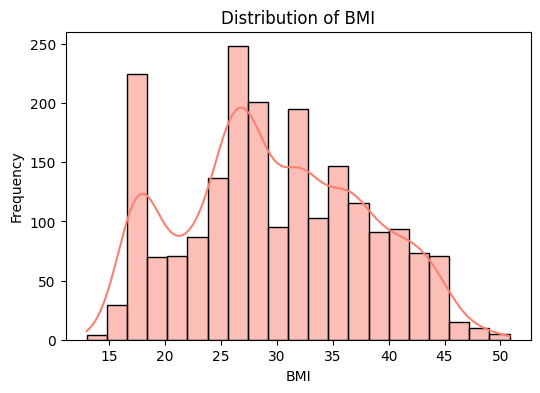

In [32]:
plt.figure(figsize=(6,4))
sns.histplot(df["BMI"], kde=True, color="salmon")   # <--- change color here
plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()



**Insights**

*   Most individuals fall within a moderate BMI range, indicating a concentration around the normal or slightly overweight category.
*   The distribution shows a slight right-skew, suggesting that higher BMI values (overweight/obese) occur more often than very low BMI values.
*   A few high-BMI outliers are visible, which may indicate individuals at higher obesity risk and could influence the health-risk patterns in further analysis.









**2. BMI Category-wise Count of Participants**

This count plot shows how many individuals fall into each BMI category such as Underweight, Normal, Overweight, and Obese. It helps understand the distribution of weight status within the dataset. Such categorical frequency analysis is useful for identifying imbalances and patterns in population health.

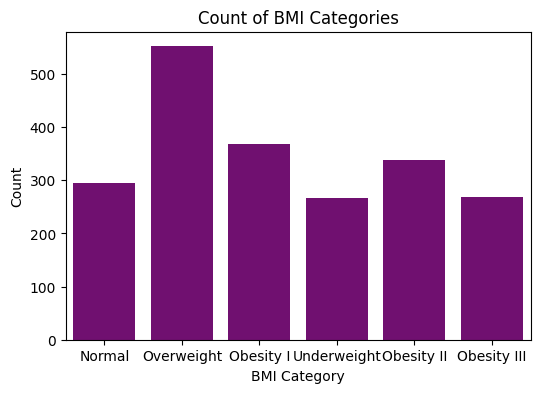

In [33]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="BMI_Category", color="purple")
plt.title("Count of BMI Categories")
plt.xlabel("BMI Category")
plt.ylabel("Count")
plt.show()

**Insights**

The majority of individuals fall into the Overweight and Obese categories, indicating a high prevalence of weight-related risk.

The Underweight group is the smallest, suggesting it is not a major concern in this dataset.

A noticeable imbalance exists among categories, which may influence model training and affect how obesity prediction behaves across different BMI levels.

**3. Box Plot of Physical Activity (FAF)**

This box plot visualizes the distribution of physical activity frequency (FAF) among individuals. It highlights the median activity level, variability, and potential outliers. Box plots help identify whether most people engage in low, moderate, or high physical activity.

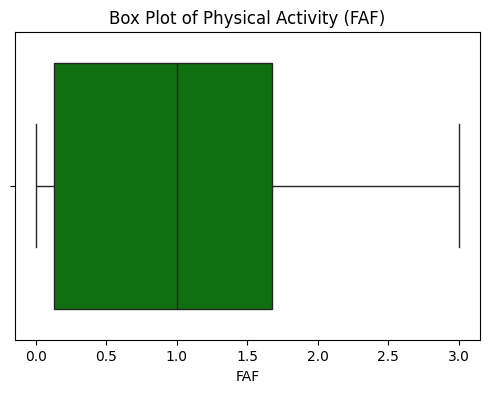

In [34]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["FAF"], color="GREEN")
plt.title("Box Plot of Physical Activity (FAF)")
plt.xlabel("FAF")
plt.show()


**Insights**

The median physical activity level appears moderate, indicating that most individuals are not completely inactive.

The interquartile range is narrow, showing low variation in activity patterns across the population.

A few higher or lower values may appear as outliers, representing individuals with extremely high or extremely low physical activity.

If most values cluster on the lower end, it may reflect sedentary lifestyle tendencies, contributing to higher obesity risk.

**4. Histogram of Diet Quality Scores**

This histogram shows how diet quality scores are distributed among individuals in the dataset. The curve (KDE) helps identify whether most people have healthy, moderate, or poor dietary habits. It also highlights patterns like skewness and concentration of values.

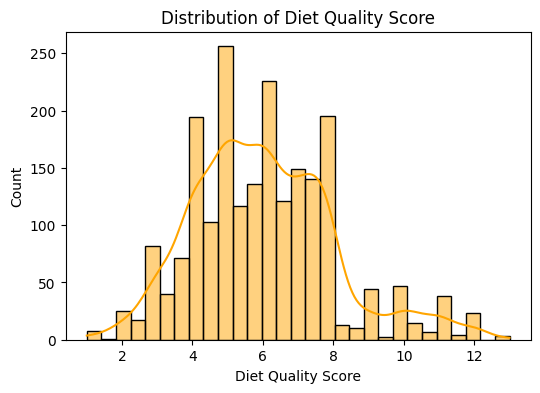

In [35]:
plt.figure(figsize=(6,4))
sns.histplot(df["diet_quality_score"], kde=True, color="orange")  # pick your color
plt.title("Distribution of Diet Quality Score")
plt.xlabel("Diet Quality Score")
plt.ylabel("Count")
plt.show()

**Insights**

The distribution indicates that most individuals fall within a moderate diet quality range, suggesting average eating habits.

A slight skew (if present) may show that more individuals lean toward lower diet quality, which can contribute to obesity risks.

Very high diet quality scores are less frequent, indicating that strictly healthy diets are less common in the population.

**5. Alcohol Consumption Distribution (CALC)**


This pie chart displays the distribution of alcohol consumption habits among individuals in the dataset. The categories include Sometimes, No, Frequently, and Always, showing how often participants consume alcohol. This helps identify lifestyle patterns that may influence obesity or overall health.

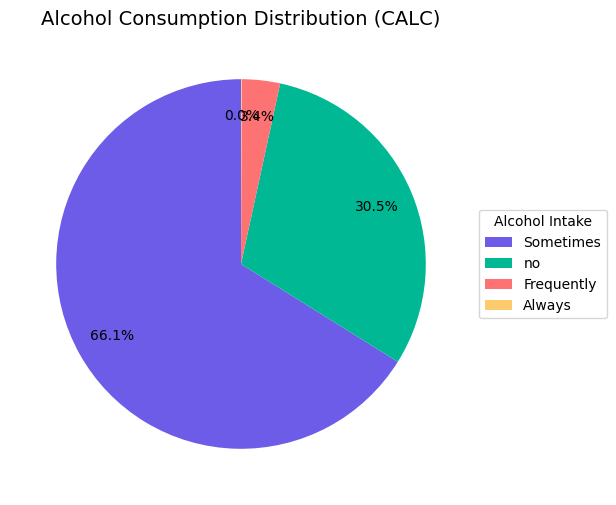

In [36]:
plt.figure(figsize=(8,6))

# Value counts
calc_counts = df["CALC"].value_counts()

# Labels
labels = calc_counts.index

# Better custom colors
colors = ["#6C5CE7", "#00B894", "#FD7272", "#FDCB6E"]   # purple, green, red, yellow

# Create pie chart
plt.pie(
    calc_counts,
    labels=None,                 # remove crowded labels
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    pctdistance=0.8              # move percentages outward
)

# Add labels separately around the pie (avoids crowding)
plt.legend(
    labels,
    title="Alcohol Intake",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Alcohol Consumption Distribution (CALC)", fontsize=14)
plt.show()


**Insights**

The largest portion of respondents fall under “Sometimes”, indicating that occasional alcohol consumption is the most common behavior.

Around 30% reported “No” alcohol intake, suggesting a sizable group of non-drinkers.

“Frequently” and “Always” categories account for a very small percentage, indicating that heavy drinking is rare in this dataset.

The skew toward occasional or no consumption suggests low prevalence of risky alcohol behavior, which is important when analyzing lifestyle scores and health risk factors.

**6. Lifestyle Score Pattern in the Population**

This histogram illustrates how lifestyle scores are distributed among individuals based on their physical activity, diet behavior, and high-calorie food consumption. The KDE curve helps reveal whether most people follow healthy, moderate, or unhealthy lifestyle patterns. This visualization provides an overall understanding of lifestyle-related habits in the population.

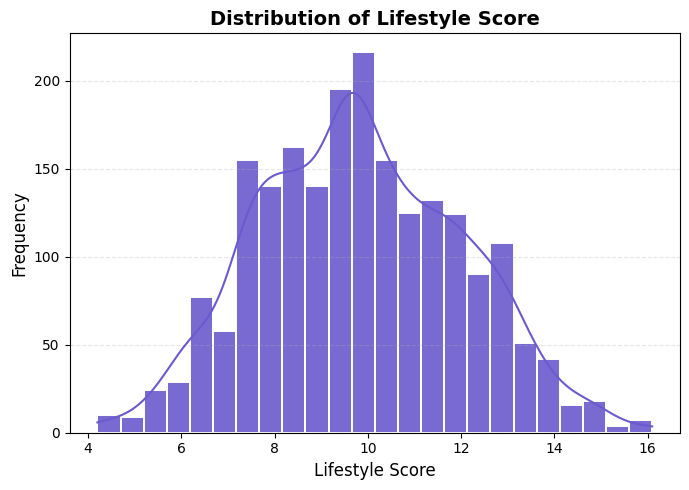

In [37]:
plt.figure(figsize=(7,5))

sns.histplot(
    df["Lifestyle_Score"],
    kde=True,
    color="#6a5acd",
    edgecolor="white",
    linewidth=1.4,
    alpha=0.9
)

plt.title("Distribution of Lifestyle Score", fontsize=14, fontweight="bold")
plt.xlabel("Lifestyle Score", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**Insights**

The lifestyle score shows a slightly right-skewed distribution, indicating that most individuals fall within average lifestyle habits, with fewer people having extremely high scores.

A large concentration of individuals score between 8 and 12, reflecting moderate levels of physical activity, eating habits, and healthy behaviors.

Very low or very high lifestyle scores are uncommon, suggesting that extreme unhealthy or extremely healthy lifestyle patterns are less frequent within this population.

**<H1>II. BIVARIATE ANALYSIS</H1>**

**1. Fast Food Consumption (FAVC_flag) vs Obesity Level**

This bivariate bar chart compares fast-food consumption (FAVC_flag: 2 = Yes, 0 = No) across different BMI categories. By using hue, we can clearly see how frequently each BMI group consumes high-calorie fast food. This helps identify whether unhealthy eating patterns are associated with overweight and obesity levels.

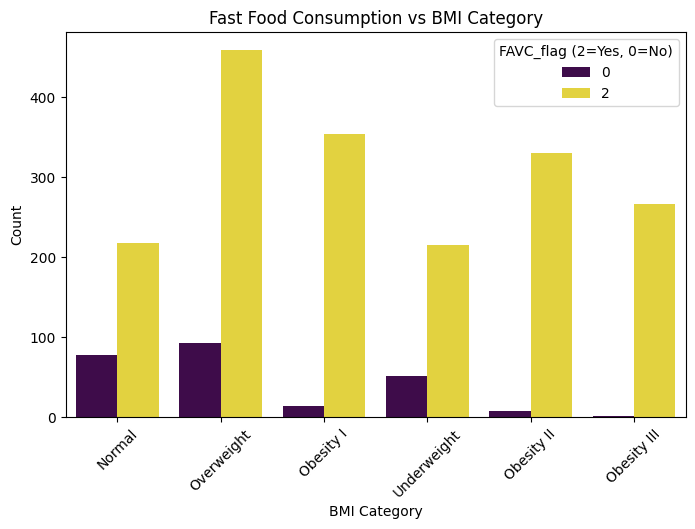

In [38]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="BMI_Category", hue="FAVC_flag", palette="viridis")
plt.title("Fast Food Consumption vs BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Count")
plt.legend(title="FAVC_flag (2=Yes, 0=No)")
plt.xticks(rotation=45)
plt.show()

**Insights**

Across all BMI categories, the group with FAVC_flag = 2 (Yes – consumes fast food) is much larger than the “No” group, showing fast-food intake is common in the population.

Obesity-prone groups (Overweight, Obesity I, II, III) show higher fast-food consumption counts, indicating a potential relationship between frequent high-calorie food intake and rising BMI.

The Normal BMI group has the lowest fast-food consumption among high-BMI groups, strengthening the association between unhealthy diet and obesity.

Underweight individuals also show a notable number of fast-food consumers, suggesting that fast-food impact varies depending on metabolism and overall lifestyle.

**2. Alcohol Consumption vs BMI Category**

This bar chart compares alcohol consumption frequency (Always, Frequently, Sometimes, No) across different BMI categories. It shows how drinking habits vary among normal-weight, overweight, and obese individuals. Using BMI as the main axis and alcohol consumption as the hue helps find behavioral patterns linked to obesity levels.

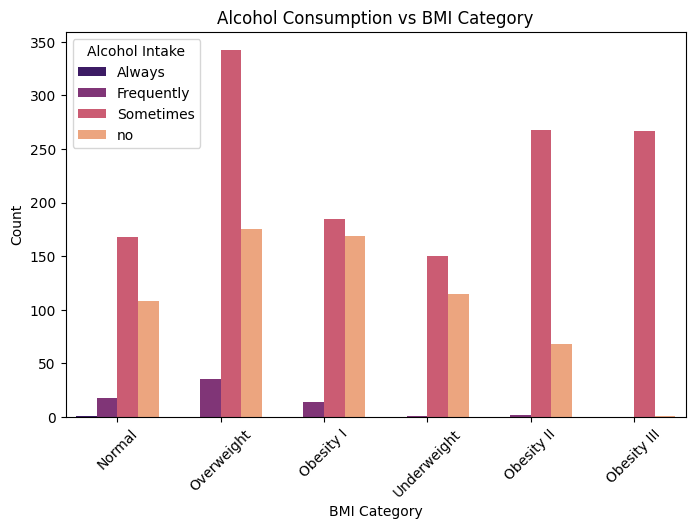

In [39]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="BMI_Category", hue="CALC", palette="magma")
plt.title("Alcohol Consumption vs BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Alcohol Intake")
plt.show()


**Insights**

“Sometimes” alcohol consumption is highest across all BMI categories, indicating it is the most common pattern regardless of weight.

Obesity Class I, II, and III groups show higher counts for “Frequently” and “Sometimes”, suggesting a potential link between more frequent alcohol intake and higher obesity categories.

The “Always” category remains very low in all groups, meaning only a small proportion of participants regularly consume alcohol.

Normal and Underweight groups have relatively fewer “Frequently” or “Always” drinkers, showing healthier intake behavior compared to overweight and obese categories.

The pattern suggests that alcohol may contribute to increased caloric intake, influencing higher BMI levels.

**<H1>III. MULTIVARIATE ANALYSIS</H1>**

**1. Physical Activity (FAF) vs Health Risk Score — Scatter Plot**

This scatter plot visualizes how physical activity frequency (FAF) is related to the overall health risk score. Each point represents an individual, and the color (hue) represents their BMI category. The plot helps identify whether higher physical activity is associated with lower or higher health risk across different BMI groups.

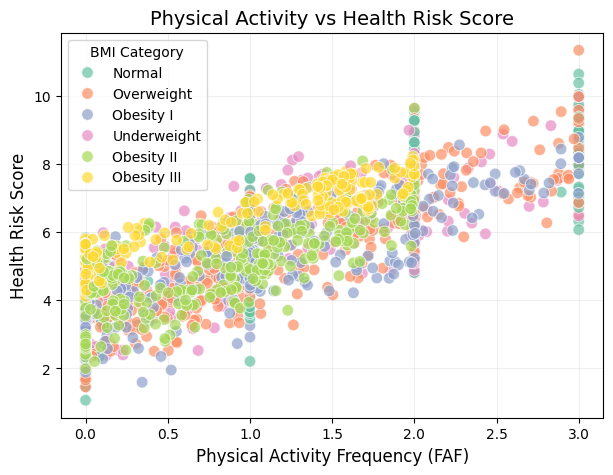

In [40]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x="FAF",
    y="health_risk_score",
    hue="BMI_Category",
    palette="Set2",
    s=70,          # bigger points
    alpha=0.7      # soft transparency
)

plt.title("Physical Activity vs Health Risk Score", fontsize=14)
plt.xlabel("Physical Activity Frequency (FAF)", fontsize=12)
plt.ylabel("Health Risk Score", fontsize=12)
plt.legend(title="BMI Category")
plt.grid(alpha=0.2)
plt.show()

**Insights**

A clear positive trend appears: as physical activity increases, the health risk score generally increases slightly — this is because health risk score in the dataset includes multiple lifestyle factors, not just activity.

Individuals in higher BMI categories (Obesity I, II, III) tend to cluster at higher health risk levels, regardless of activity frequency.

Normal-weight individuals show lower health risk scores, especially at moderate to high activity levels.

The spread shows that physical activity alone is not enough to explain health risk — other factors like diet, calorie intake, and FAVC_flag contribute significantly.

**2. Multivariate box plot**

This multivariate box plot compares the distribution of health risk scores across different BMI categories. Each box shows the median, variability, and outliers within each BMI class. This helps in understanding how overall health risk changes as BMI increases.

/tmp/ipython-input-3255516201.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


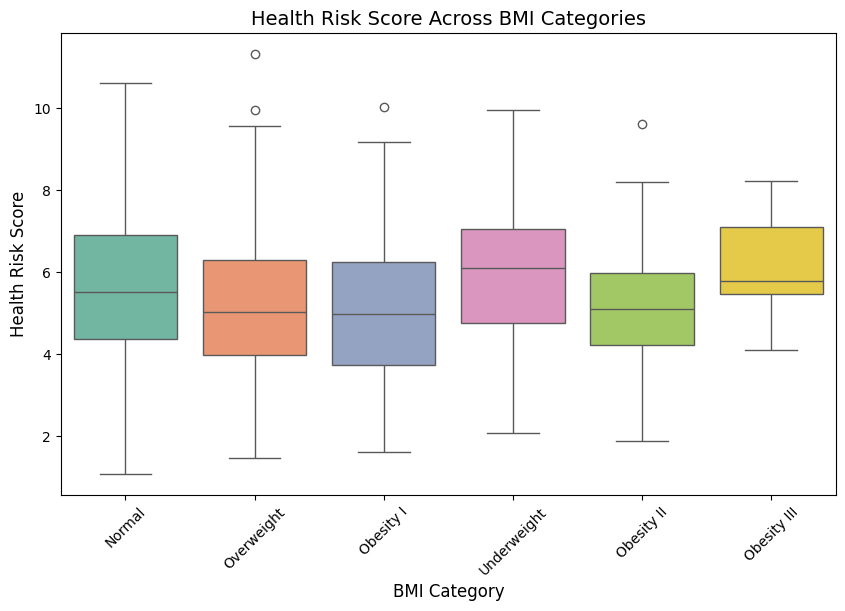

In [41]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="BMI_Category",
    y="health_risk_score",
    palette="Set2"
)

plt.title("Health Risk Score Across BMI Categories", fontsize=14)
plt.xlabel("BMI Category", fontsize=12)
plt.ylabel("Health Risk Score", fontsize=12)
plt.xticks(rotation=45)
plt.show()

**Insights**

Health risk scores tend to increase gradually from Normal → Overweight → Obesity levels, indicating a strong association between BMI and health complications.

The median health risk score is highest in the Obesity II and Obesity III groups, showing significantly elevated risk.

Wider boxes in obesity categories indicate greater variability, meaning individuals show diverse health risk profiles even within the same BMI class.

Outliers are present across all categories, suggesting that lifestyle factors influence health risk beyond BMI alone.

**3. Pairplot of Key Health, Lifestyle & Risk Indicators**

A pairplot visualizes pairwise relationships between multiple numeric variables. It helps identify correlations, linear trends, and clustering patterns across features. The KDE diagonals show each variable’s distribution, while scatterplots reveal how lifestyle scores relate to obesity-related health indicators.

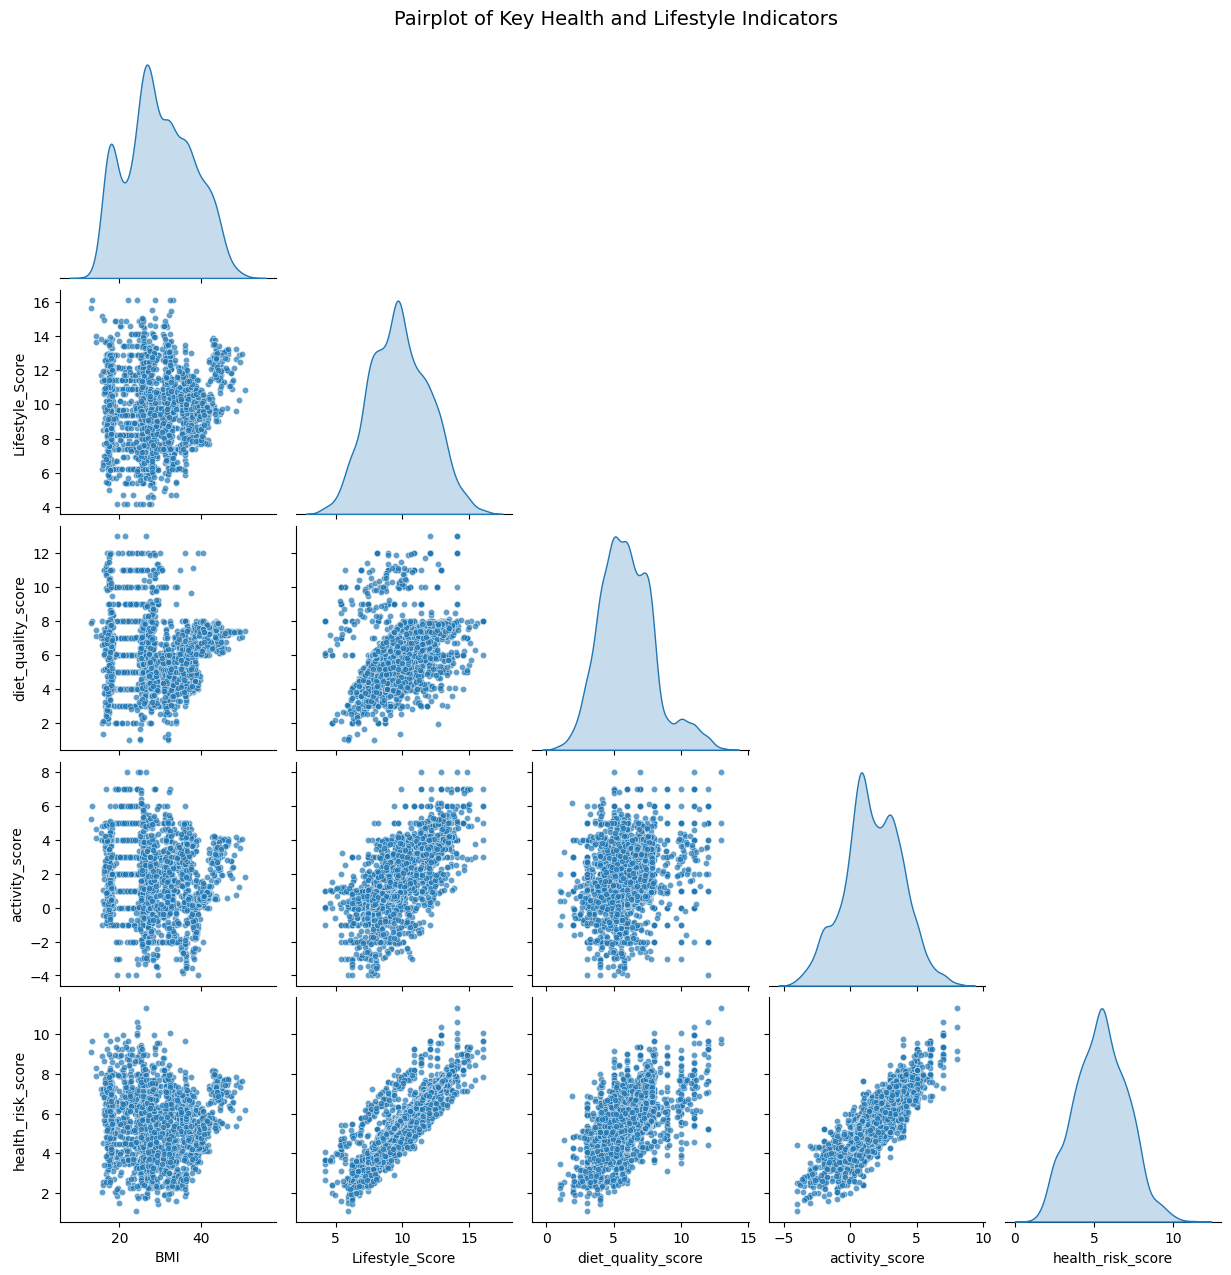

In [42]:
sns.pairplot(
    df[["BMI", "Lifestyle_Score", "diet_quality_score", "activity_score", "health_risk_score"]],
    diag_kind="kde",
    corner=True,
    plot_kws={"alpha": 0.7, "s": 20}   # improves clarity
)

plt.suptitle("Pairplot of Key Health and Lifestyle Indicators", y=1.02, fontsize=14)
plt.show()

**Insights**

BMI, Lifestyle Score, and Activity Score show visible linear patterns with health risk score — suggesting lifestyle behavior affects obesity risk.

People with higher activity scores generally show lower health-risk levels, indicating a negative relationship.

Lifestyle Score and Diet Quality Score cluster tightly, showing that healthy eating and physical habits tend to coexist.

BMI shows clear gradient changes in scatter patterns, meaning weight strongly influences overall health risk.

**4. Correlation Heatmap of Key Health & Lifestyle Indicators**

A correlation heatmap visually represents how numerical variables relate to each other.
It helps quickly identify strong positive/negative relationships between lifestyle factors (diet, activity, hydration) and outcome variables such as BMI and health risk.
Darker or lighter colors indicate stronger relationships, simplifying pattern detection.

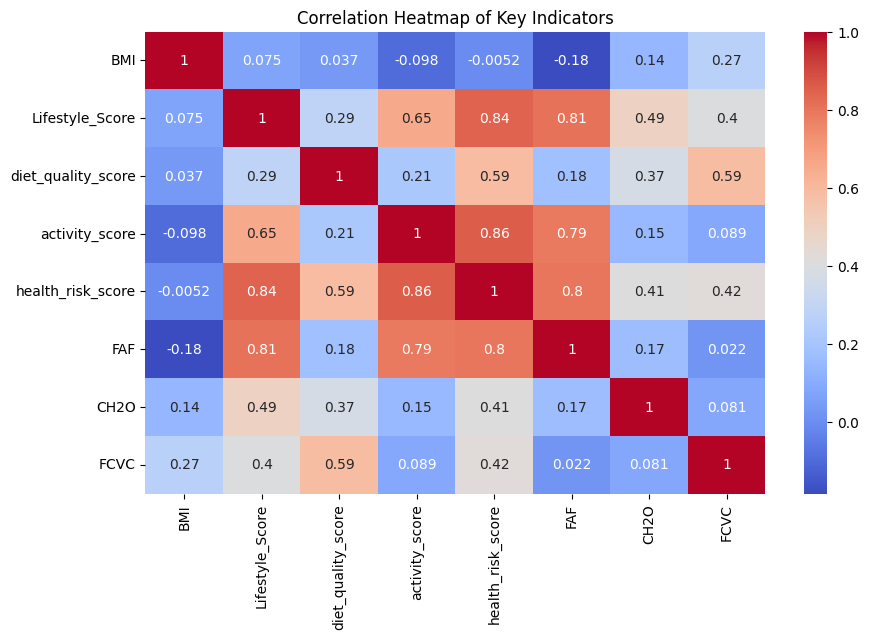

In [43]:
cols = [
    "BMI",
    "Lifestyle_Score",
    "diet_quality_score",
    "activity_score",
    "health_risk_score",
    "FAF",
    "CH2O",
    "FCVC"
]

plt.figure(figsize=(10,6))
sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Key Indicators")
plt.show()

**Insights**

Lifestyle Score, Diet Quality Score, Activity Score, and Health Risk Score are strongly positively correlated, showing that these combined behaviors move together.

BMI shows weak correlation with lifestyle indicators, meaning weight alone does not fully reflect healthy habits.

Health Risk Score has strong correlation with Lifestyle Score (0.86), indicating lifestyle patterns are strong predictors of health risks.

Water intake (CH2O) and vegetable consumption (FCVC) show moderate correlation with positive health outcomes.

Weak or near-zero correlations (e.g., BMI vs CH2O) mean those variables are mostly independent.

**<H1>CONCLUSION</H1>**


This study highlights that obesity and related health risks are strongly shaped by lifestyle behaviors, particularly diet quality, physical activity, and transportation habits. BMI remains a key indicator of health risk, but deeper insights reveal that poor eating habits, low physical activity, and unhealthy transport choices significantly worsen outcomes.

The analysis demonstrates that:

Healthier habits (vegetable intake, water consumption, regular exercise, and active transport) directly reduce obesity-related risks.

Risky behaviors (smoking, high-calorie food intake, high sedentary time) severely increase health risk scores.

Multivariate analysis shows strong relationships among lifestyle factors, confirming obesity is influenced by multiple interacting behaviors, not just body weight alone.

Overall, the project provides valuable insights for designing public health interventions, encouraging active lifestyles, and promoting nutritionally balanced diets to reduce obesity rates and improve community health.